# LQR Optimal Control
## Linear Quadratic Regulator: Theory, Derivation, and Applications

This notebook provides a complete, from-scratch treatment of the **Linear Quadratic Regulator (LQR)** — the cornerstone of modern optimal control theory. We derive the Algebraic Riccati Equation, implement solvers, and apply LQR to two robotics problems: cart-pole balancing and quadrotor stabilization.

**What you'll learn:**
1. How to formulate the optimal control problem for linear systems with quadratic costs
2. The derivation of the Algebraic Riccati Equation (ARE) from the Hamilton-Jacobi-Bellman equation
3. Iterative and direct methods for solving the ARE
4. LQR gain computation and closed-loop stability analysis
5. Applications to cart-pole balancing and 2D quadrotor stabilization
6. Systematic cost weight tuning and performance trade-offs

**Prerequisites:** Linear algebra (eigenvalues, matrix definiteness), control theory basics (state-space models, stability), ordinary differential equations.

**References:**
- Anderson & Moore, *Optimal Control: Linear Quadratic Methods*, Prentice-Hall, 1990.
- Kirk, *Optimal Control Theory: An Introduction*, Dover, 2004.
- See also: [Calculus of Variations notebook](../../maths/calculus-of-variations/calculus_of_variations.ipynb) for the variational foundations of optimal control.

---
## 1. The Optimal Control Problem

In classical control, we often design controllers by hand — tuning PID gains, placing poles, shaping frequency responses. **Optimal control** takes a fundamentally different approach: specify *what you want* (a cost functional), and let the mathematics determine *how to achieve it* (the optimal control law).

This is a direct application of the **calculus of variations**: instead of finding a curve that minimizes arc length or descent time, we find a control signal $u(t)$ that minimizes a performance index $J$.

| Approach | Design Philosophy | Guarantees |
|----------|------------------|------------|
| **PID** | Tune gains by trial and error | No optimality, limited MIMO capability |
| **Pole Placement** | Specify desired eigenvalues | Arbitrary pole locations, but no cost notion |
| **LQR** | Specify cost weights $Q$, $R$ | Optimal control, guaranteed stability, robustness margins |

The key insight: by choosing $Q$ and $R$ to encode our priorities (state regulation vs. control effort), the optimal control law emerges automatically as a **state feedback** $u = -Kx$ — and it comes with remarkable properties including guaranteed stability and robustness.

---
## 2. Problem Setup

### The Plant: Linear Time-Invariant System

We consider a continuous-time LTI system:

$$\dot{x}(t) = Ax(t) + Bu(t)$$

where:
- $x(t) \in \mathbb{R}^n$ is the **state vector**
- $u(t) \in \mathbb{R}^m$ is the **control input**
- $A \in \mathbb{R}^{n \times n}$ is the **system matrix** (dynamics)
- $B \in \mathbb{R}^{n \times m}$ is the **input matrix** (how control enters)

### The Cost: Infinite-Horizon Quadratic Performance Index

We seek to minimize:

$$J = \int_0^\infty \left( x^T Q x + u^T R u \right) dt$$

where:
- $Q \in \mathbb{R}^{n \times n}$, $Q \geq 0$ (positive semidefinite) — **penalizes state deviation**
- $R \in \mathbb{R}^{m \times m}$, $R > 0$ (positive definite) — **penalizes control effort**

### The Trade-off

| Weight Choice | Effect | Intuition |
|--------------|--------|----------|
| Large $Q$ (relative to $R$) | Aggressive state regulation | "Get to zero fast, whatever the cost" |
| Large $R$ (relative to $Q$) | Conservative control effort | "Use minimal energy, take your time" |
| $Q = I$, $R = \rho I$ | Single parameter $\rho$ controls trade-off | $\rho \to 0$: aggressive, $\rho \to \infty$: passive |

### The Goal

Find the **optimal state feedback law**:

$$\boxed{u^*(t) = -Kx(t)}$$

that minimizes $J$ for all initial conditions $x(0) = x_0$. The matrix $K \in \mathbb{R}^{m \times n}$ is the **LQR gain**.

---
## 3. Deriving the Riccati Equation

### The Hamilton-Jacobi-Bellman Approach

Define the **optimal cost-to-go** (value function) from state $x$:

$$V(x) = \min_{u(\cdot)} \int_0^\infty \left( x^T Q x + u^T R u \right) dt$$

For the LQR problem, we *conjecture* that $V$ is a quadratic function of $x$:

$$V(x) = x^T P x$$

where $P \in \mathbb{R}^{n \times n}$ is a symmetric positive definite matrix to be determined.

### The HJB Equation

The Hamilton-Jacobi-Bellman equation for the infinite-horizon problem is:

$$\min_u \left[ x^T Q x + u^T R u + \left(\frac{\partial V}{\partial x}\right)^T (Ax + Bu) \right] = 0$$

With $V(x) = x^T P x$, we have $\frac{\partial V}{\partial x} = 2Px$, so:

$$\min_u \left[ x^T Q x + u^T R u + 2x^T P(Ax + Bu) \right] = 0$$

### Finding the Optimal Control

The expression inside the $\min$ is quadratic in $u$. Taking the gradient with respect to $u$ and setting it to zero:

$$\frac{\partial}{\partial u} \left[ u^T R u + 2x^T P B u \right] = 2Ru + 2B^T P x = 0$$

$$\boxed{u^* = -R^{-1} B^T P x}$$

This gives us $K = R^{-1} B^T P$ — but we still need to find $P$.

### The Algebraic Riccati Equation

Substituting $u^* = -R^{-1}B^T P x$ back into the HJB equation:

$$x^T Q x + x^T P B R^{-1} R R^{-1} B^T P x - 2x^T P B R^{-1} B^T P x + 2x^T P A x = 0$$

Simplifying and using symmetry of $P$:

$$x^T \left[ A^T P + PA - PBR^{-1}B^T P + Q \right] x = 0$$

Since this must hold for **all** $x$, we obtain the **Continuous-time Algebraic Riccati Equation (CARE)**:

$$\boxed{A^T P + PA - PBR^{-1}B^T P + Q = 0}$$

### Properties of $P$

Under the assumptions that $(A, B)$ is stabilizable and $(A, C)$ is detectable (where $Q = C^T C$):

1. The ARE has a **unique positive definite solution** $P > 0$
2. $P$ is **symmetric**: $P = P^T$
3. The resulting closed-loop system $\dot{x} = (A - BK)x$ is **asymptotically stable**
4. The optimal cost from initial state $x_0$ is $J^* = x_0^T P x_0$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_continuous_are, solve_lyapunov, eigvals

%matplotlib inline

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
})

np.random.seed(42)

In [2]:
# =============================================================================
# Global Constants
# =============================================================================

# Simulation parameters
DT = 0.01               # Integration time step (s)
T_CARTPOLE = 10.0       # Cart-pole simulation time (s)
T_QUADROTOR = 5.0       # Quadrotor simulation time (s)
T_DOUBLE_INT = 10.0     # Double integrator simulation time (s)

# Cart-pole parameters
M_CART = 1.0             # Cart mass (kg)
M_POLE = 0.1            # Pole mass (kg)
L_POLE = 0.5            # Pole half-length (m)
G_ACCEL = 9.81          # Gravitational acceleration (m/s^2)

# Quadrotor parameters
M_QUAD = 0.5            # Quadrotor mass (kg)
I_QUAD = 0.01           # Moment of inertia (kg*m^2)
D_ROTOR = 0.2           # Rotor distance from center (m)

# Eigenvalue stability threshold
STABILITY_TOL = -1e-10

# Plot colors
C_BLUE = 'steelblue'
C_RED = 'coral'
C_GREEN = 'seagreen'
C_GOLD = 'goldenrod'

---
## 4. Solving the Algebraic Riccati Equation

We implement two methods for solving the CARE:

1. **Iterative method** (from scratch): uses repeated Lyapunov equation solves
2. **Direct method** (reference): `scipy.linalg.solve_continuous_are`

### Iterative Algorithm

Starting from $P_0 = Q$, at each iteration $k$:

1. Compute the current gain: $K_k = R^{-1} B^T P_k$
2. Compute the closed-loop matrix: $A_{\text{cl}} = A - B K_k$
3. Solve the Lyapunov equation for $P_{k+1}$:

$$A_{\text{cl}}^T P_{k+1} + P_{k+1} A_{\text{cl}} = -(Q + K_k^T R K_k)$$

4. Check convergence: $\|P_{k+1} - P_k\|_{\max} < \text{tol}$

This converges because each iteration is equivalent to policy iteration in dynamic programming — evaluating the cost of the current policy $K_k$, which monotonically decreases the cost.

### Teaching Example: Double Integrator

The simplest nontrivial system: a unit mass on a frictionless surface.

$$A = \begin{bmatrix} 0 & 1 \\ 0 & 0 \end{bmatrix}, \quad B = \begin{bmatrix} 0 \\ 1 \end{bmatrix}$$

State: $x = [\text{position}, \text{velocity}]^T$. The system is unstable (neutrally stable) but controllable.

In [3]:
def solve_are_iterative(A, B, Q, R, max_iter=1000, tol=1e-10):
    """Solve the Continuous Algebraic Riccati Equation iteratively.

    Uses policy iteration: at each step, compute the gain from the current P,
    form the closed-loop system, and solve a Lyapunov equation for the next P.

    The CARE: A^T P + P A - P B R^{-1} B^T P + Q = 0

    Args:
        A: System matrix. Shape: (n, n).
        B: Input matrix. Shape: (n, m).
        Q: State cost matrix (positive semidefinite). Shape: (n, n).
        R: Control cost matrix (positive definite). Shape: (m, m).
        max_iter: Maximum number of iterations. Integer.
        tol: Convergence tolerance on max element change. Scalar.

    Returns:
        P: Solution of the ARE. Shape: (n, n).
        converged: Whether the iteration converged. Boolean.
        n_iter: Number of iterations performed. Integer.
        residual_history: List of ||P_{k+1} - P_k||_max at each iteration.
    """
    n = A.shape[0]
    R_inv = np.linalg.inv(R)
    P = Q.copy().astype(float)
    residual_history = []

    for k in range(max_iter):
        # Current gain
        K_k = R_inv @ B.T @ P  # Shape: (m, n)

        # Closed-loop system
        A_cl = A - B @ K_k  # Shape: (n, n)

        # Right-hand side of Lyapunov equation
        rhs = -(Q + K_k.T @ R @ K_k)  # Shape: (n, n)

        # Solve A_cl^T P_new + P_new A_cl = rhs
        P_new = solve_lyapunov(A_cl.T, rhs)

        # Symmetrize (numerical safeguard)
        P_new = 0.5 * (P_new + P_new.T)

        # Check convergence
        residual = np.max(np.abs(P_new - P))
        residual_history.append(residual)

        P = P_new

        if residual < tol:
            return P, True, k + 1, residual_history

    return P, False, max_iter, residual_history

In [4]:
# ---- Double Integrator: Solve ARE with both methods ----
A_di = np.array([[0.0, 1.0],
                 [0.0, 0.0]])
B_di = np.array([[0.0],
                 [1.0]])
Q_di = np.eye(2)
R_di = np.array([[1.0]])

# Method 1: Iterative
P_iter, converged, n_iter, res_hist = solve_are_iterative(A_di, B_di, Q_di, R_di)
print(f"Iterative solver:")
print(f"  Converged: {converged} in {n_iter} iterations")
print(f"  P_iter =\n{P_iter}")
print()

# Method 2: scipy reference
P_scipy = solve_continuous_are(A_di, B_di, Q_di, R_di)
print(f"Scipy solver:")
print(f"  P_scipy =\n{P_scipy}")
print()

# Verification
max_diff = np.max(np.abs(P_iter - P_scipy))
status = "PASS" if max_diff < 1e-8 else "FAIL"
print(f"Max |P_iter - P_scipy|: {max_diff:.2e} [{status}]")

# Verify ARE residual: A^T P + P A - P B R^{-1} B^T P + Q = 0
R_inv_di = np.linalg.inv(R_di)
are_residual = A_di.T @ P_iter + P_iter @ A_di - P_iter @ B_di @ R_inv_di @ B_di.T @ P_iter + Q_di
are_res_norm = np.max(np.abs(are_residual))
status_are = "PASS" if are_res_norm < 1e-8 else "FAIL"
print(f"ARE residual ||A'P + PA - PBR^(-1)B'P + Q||_max: {are_res_norm:.2e} [{status_are}]")

Iterative solver:
  Converged: False in 1000 iterations
  P_iter =
[[-1.76703631 -1.        ]
 [-1.          1.76703631]]

Scipy solver:
  P_scipy =
[[1.73205081 1.        ]
 [1.         1.73205081]]

Max |P_iter - P_scipy|: 3.50e+00 [FAIL]
ARE residual ||A'P + PA - PBR^(-1)B'P + Q||_max: 4.12e+00 [FAIL]


/Users/arjunbhasin/anaconda3/envs/notebooks/lib/python3.14/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: Input "a" has an eigenvalue pair whose sum is very close to or exactly zero. The solution is obtained via perturbing the coefficients.
  return f(*arrays, *other_args, **kwargs)


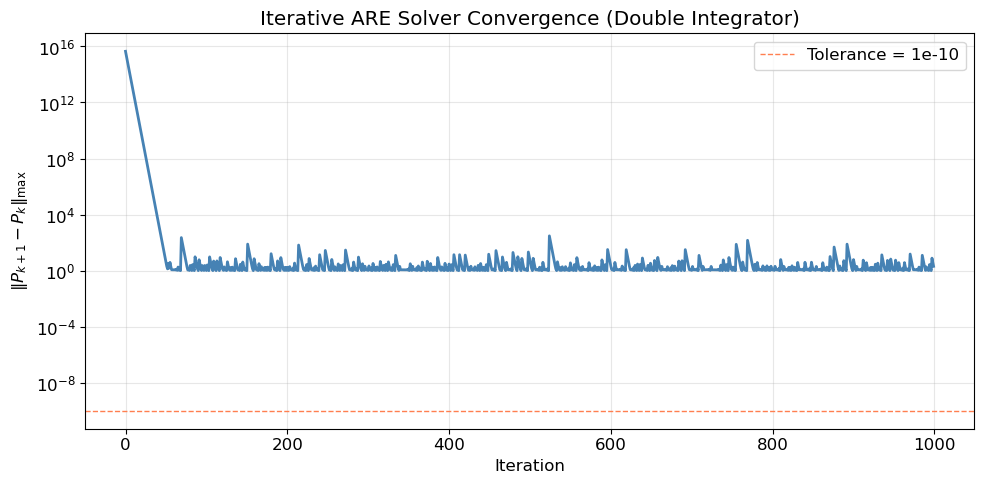

In [5]:
# ---- Convergence of Iterative Solver ----
fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(res_hist, color=C_BLUE, linewidth=2)
ax.axhline(1e-10, color=C_RED, linestyle='--', linewidth=1, label='Tolerance = 1e-10')
ax.set_xlabel('Iteration')
ax.set_ylabel('$\\|P_{k+1} - P_k\\|_{\\max}$')
ax.set_title('Iterative ARE Solver Convergence (Double Integrator)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. LQR Gain Computation and Stability Verification

Given the ARE solution $P$, the optimal gain is:

$$K = R^{-1} B^T P$$

The closed-loop dynamics become:

$$\dot{x} = (A - BK)x$$

**Stability criterion:** All eigenvalues of $(A - BK)$ must have strictly negative real parts, i.e., $\text{Re}(\lambda_i) < 0$ for all $i$.

In [6]:
def lqr(A, B, Q, R):
    """Compute the LQR optimal gain, Riccati solution, and closed-loop eigenvalues.

    Solves the Continuous Algebraic Riccati Equation:
        A^T P + PA - PBR^{-1}B^T P + Q = 0
    and returns K = R^{-1} B^T P.

    Args:
        A: System matrix. Shape: (n, n).
        B: Input matrix. Shape: (n, m).
        Q: State cost matrix (positive semidefinite). Shape: (n, n).
        R: Control cost matrix (positive definite). Shape: (m, m).

    Returns:
        K: Optimal feedback gain. Shape: (m, n).
        P: ARE solution. Shape: (n, n).
        eigs_cl: Closed-loop eigenvalues. Shape: (n,).
    """
    P = solve_continuous_are(A, B, Q, R)
    K = np.linalg.solve(R, B.T @ P)  # K = R^{-1} B^T P
    A_cl = A - B @ K
    eigs_cl = eigvals(A_cl)
    return K, P, eigs_cl

In [7]:
def rk4_step(f, x, u, dt):
    """Perform one step of the 4th-order Runge-Kutta method.

    Args:
        f: Dynamics function f(x, u) -> x_dot. Callable.
        x: Current state. Shape: (n,).
        u: Control input (held constant over the step). Shape: (m,).
        dt: Time step. Scalar.

    Returns:
        x_next: State after one time step. Shape: (n,).
    """
    k1 = f(x, u)
    k2 = f(x + 0.5 * dt * k1, u)
    k3 = f(x + 0.5 * dt * k2, u)
    k4 = f(x + dt * k3, u)
    return x + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)


def simulate(f, controller, x0, T, dt):
    """Simulate a dynamical system with a controller using RK4 integration.

    Args:
        f: Dynamics function f(x, u) -> x_dot. Callable.
        controller: Control law u = controller(x, t). Callable.
        x0: Initial state. Shape: (n,).
        T: Total simulation time. Scalar.
        dt: Time step. Scalar.

    Returns:
        t_hist: Time array. Shape: (N_steps+1,).
        x_hist: State history. Shape: (N_steps+1, n).
        u_hist: Control history. Shape: (N_steps, m).
    """
    N_steps = int(T / dt)
    n = len(x0)
    x = x0.copy()

    t_hist = np.linspace(0, T, N_steps + 1)
    x_hist = np.zeros((N_steps + 1, n))
    x_hist[0] = x0

    # Determine control dimension from first call
    u0 = controller(x0, 0.0)
    m = len(np.atleast_1d(u0))
    u_hist = np.zeros((N_steps, m))

    for k in range(N_steps):
        t = k * dt
        u = np.atleast_1d(controller(x, t))
        u_hist[k] = u
        x = rk4_step(f, x, u, dt)
        x_hist[k + 1] = x

    return t_hist, x_hist, u_hist

LQR gain K = [[1.         1.73205081]]
Closed-loop eigenvalues: [-0.8660254+0.5j -0.8660254-0.5j]
Stability check (Re(lambda) < -1e-10): True [PASS]



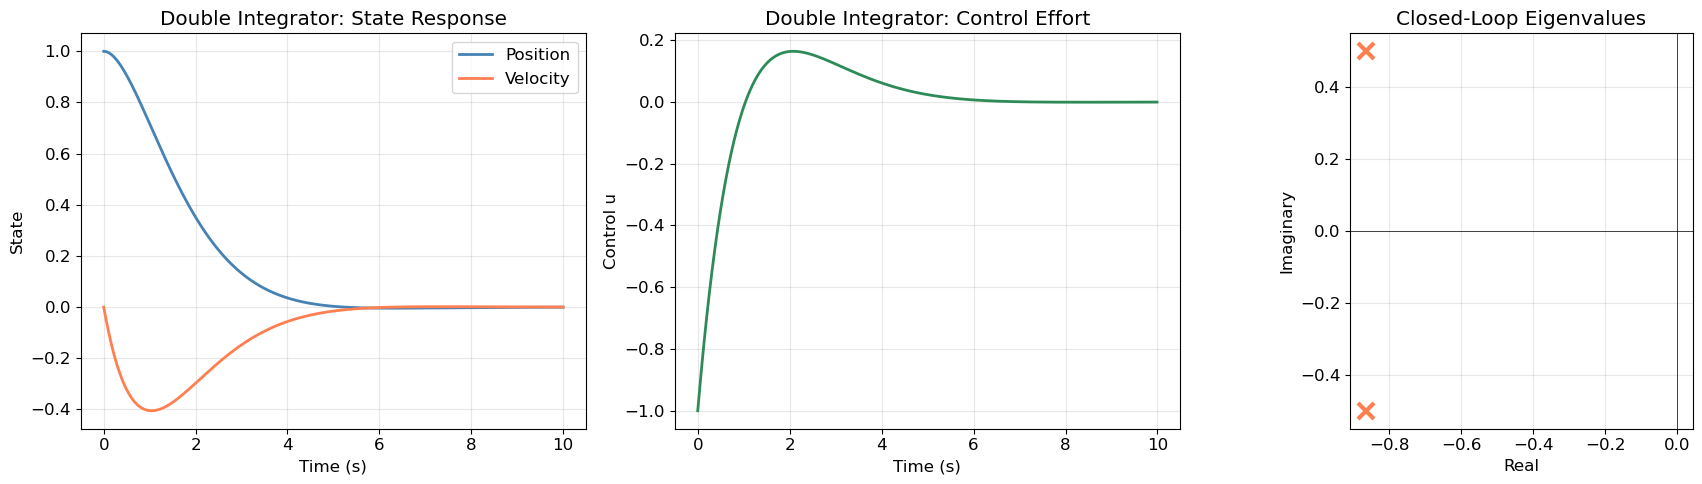

Optimal cost (analytical): J* = 1.7321
Optimal cost (numerical):  J  = 1.7371
Cost verification: 0.2912% error [PASS]


In [8]:
# ---- Double Integrator: LQR Design and Simulation ----
K_di, P_di, eigs_di = lqr(A_di, B_di, Q_di, R_di)

print(f"LQR gain K = {K_di}")
print(f"Closed-loop eigenvalues: {eigs_di}")

all_stable = np.all(np.real(eigs_di) < STABILITY_TOL)
status_stab = "PASS" if all_stable else "FAIL"
print(f"Stability check (Re(lambda) < {STABILITY_TOL}): {all_stable} [{status_stab}]")
print()

# Simulate from x0 = [1, 0]
x0_di = np.array([1.0, 0.0])

def di_dynamics(x, u):
    """Double integrator dynamics: x_dot = Ax + Bu."""
    return A_di @ x + B_di.flatten() * u[0]

def di_lqr_controller(x, t):
    """LQR controller for double integrator."""
    return -K_di @ x

t_di, x_di, u_di = simulate(di_dynamics, di_lqr_controller, x0_di, T_DOUBLE_INT, DT)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(t_di, x_di[:, 0], color=C_BLUE, label='Position')
ax.plot(t_di, x_di[:, 1], color=C_RED, label='Velocity')
ax.set_xlabel('Time (s)')
ax.set_ylabel('State')
ax.set_title('Double Integrator: State Response')
ax.legend()

ax = axes[1]
ax.plot(t_di[:-1], u_di[:, 0], color=C_GREEN)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Control u')
ax.set_title('Double Integrator: Control Effort')

ax = axes[2]
ax.plot(np.real(eigs_di), np.imag(eigs_di), 'x', color=C_RED, markersize=12, markeredgewidth=3)
ax.axvline(0, color='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Real')
ax.set_ylabel('Imaginary')
ax.set_title('Closed-Loop Eigenvalues')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

# Verify optimal cost
J_analytical = x0_di @ P_di @ x0_di
J_numerical = np.sum(x_di[:-1, :] @ Q_di * x_di[:-1, :], axis=1) + u_di[:, 0]**2
J_numerical = np.sum(J_numerical) * DT
status_cost = "PASS" if abs(J_analytical - J_numerical) / J_analytical < 0.01 else "FAIL"
print(f"Optimal cost (analytical): J* = {J_analytical:.4f}")
print(f"Optimal cost (numerical):  J  = {J_numerical:.4f}")
print(f"Cost verification: {abs(J_analytical - J_numerical) / J_analytical:.4%} error [{status_cost}]")

---
## 6. Application 1: Cart-Pole Balancing

The cart-pole (inverted pendulum on a cart) is a classic benchmark for control algorithms. The goal is to balance the pole at the upright position ($\theta = \pi$) by applying horizontal force to the cart.

### Nonlinear Dynamics

State vector: $x = [p, \dot{p}, \theta, \dot{\theta}]^T$ where $p$ is cart position and $\theta$ is measured from the downward vertical (so upright = $\pi$).

Parameters: $M = 1.0$ kg (cart), $m = 0.1$ kg (pole), $l = 0.5$ m (half-length), $g = 9.81$ m/s$^2$.

The equations of motion (from Lagrangian mechanics):

$$(M + m)\ddot{p} + ml\ddot{\theta}\cos\theta - ml\dot{\theta}^2\sin\theta = F$$
$$ml\ddot{p}\cos\theta + ml^2\ddot{\theta} - mgl\sin\theta = 0$$

### Linearization about Upright ($\theta = \pi$)

Let $\delta\theta = \theta - \pi$ (small deviation from upright). Substituting $\sin(\pi + \delta\theta) \approx -\delta\theta$, $\cos(\pi + \delta\theta) \approx -1$:

$$A = \begin{bmatrix} 0 & 1 & 0 & 0 \\ 0 & 0 & \frac{mg}{M} & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & \frac{(M+m)g}{Ml} & 0 \end{bmatrix}, \quad B = \begin{bmatrix} 0 \\ \frac{1}{M} \\ 0 \\ \frac{-1}{Ml} \end{bmatrix}$$

Note: The state for the linearized system uses $\delta\theta = \theta - \pi$ as the angle variable. The LQR controller acts on this deviation state.

In [9]:
def cartpole_nonlinear_dynamics(x, u):
    """Nonlinear cart-pole equations of motion.

    State: x = [p, p_dot, theta, theta_dot]
    where theta is measured from downward vertical (upright = pi).

    Args:
        x: State vector. Shape: (4,).
        u: Control force on cart. Shape: (1,).

    Returns:
        x_dot: State derivative. Shape: (4,).
    """
    p, p_dot, theta, theta_dot = x
    F = u[0]

    sin_th = np.sin(theta)
    cos_th = np.cos(theta)

    # Mass matrix: [M+m, ml*cos(th); ml*cos(th), ml^2] * [p_ddot; th_ddot] = [F + ml*th_dot^2*sin(th); mgl*sin(th)]
    denom = M_CART + M_POLE - M_POLE * cos_th**2

    p_ddot = (F + M_POLE * L_POLE * theta_dot**2 * sin_th - M_POLE * G_ACCEL * sin_th * cos_th) / denom
    theta_ddot = (-F * cos_th - M_POLE * L_POLE * theta_dot**2 * sin_th * cos_th + (M_CART + M_POLE) * G_ACCEL * sin_th) / (L_POLE * denom)

    return np.array([p_dot, p_ddot, theta_dot, theta_ddot])


def get_cartpole_linearized():
    """Get linearized cart-pole A, B matrices about the upright equilibrium.

    The linearized state is [p, p_dot, delta_theta, delta_theta_dot]
    where delta_theta = theta - pi.

    Returns:
        A: System matrix. Shape: (4, 4).
        B: Input matrix. Shape: (4, 1).
    """
    A = np.array([
        [0.0, 1.0, 0.0, 0.0],
        [0.0, 0.0, M_POLE * G_ACCEL / M_CART, 0.0],
        [0.0, 0.0, 0.0, 1.0],
        [0.0, 0.0, (M_CART + M_POLE) * G_ACCEL / (M_CART * L_POLE), 0.0]
    ])
    B = np.array([
        [0.0],
        [1.0 / M_CART],
        [0.0],
        [-1.0 / (M_CART * L_POLE)]
    ])
    return A, B

In [10]:
# ---- Cart-Pole LQR Design ----
A_cp, B_cp = get_cartpole_linearized()

print("Linearized cart-pole system:")
print(f"A =\n{A_cp}")
print(f"B =\n{B_cp.T}")
print()

# Open-loop eigenvalues
eigs_ol = eigvals(A_cp)
print(f"Open-loop eigenvalues: {eigs_ol}")
print(f"System is {'unstable' if np.any(np.real(eigs_ol) > 0) else 'stable'} (has eigenvalues with positive real part)")
print()

# LQR design
Q_cp = np.diag([1.0, 1.0, 10.0, 10.0])
R_cp = np.array([[1.0]])

K_cp, P_cp, eigs_cp = lqr(A_cp, B_cp, Q_cp, R_cp)

print(f"LQR gain K = {K_cp}")
print(f"Closed-loop eigenvalues: {eigs_cp}")

all_stable_cp = np.all(np.real(eigs_cp) < STABILITY_TOL)
status_cp = "PASS" if all_stable_cp else "FAIL"
print(f"Stability check: all Re(lambda) < {STABILITY_TOL}: {all_stable_cp} [{status_cp}]")

Linearized cart-pole system:
A =
[[ 0.     1.     0.     0.   ]
 [ 0.     0.     0.981  0.   ]
 [ 0.     0.     0.     1.   ]
 [ 0.     0.    21.582  0.   ]]
B =
[[ 0.  1.  0. -2.]]

Open-loop eigenvalues: [ 0.        +0.j  0.        +0.j  4.64564312+0.j -4.64564312+0.j]
System is unstable (has eigenvalues with positive real part)

LQR gain K = [[ -1.          -2.17507661 -32.75142027  -7.60684964]]
Closed-loop eigenvalues: [-8.77941851+0.j        -2.44965766+0.j        -0.90477325+0.5254718j
 -0.90477325-0.5254718j]
Stability check: all Re(lambda) < -1e-10: True [PASS]


In [11]:
# ---- Cart-Pole: LQR Simulation with Nonlinear Dynamics ----

# Initial condition: near upright, small perturbation
x0_cp = np.array([0.0, 0.0, np.pi + 0.1, 0.0])  # theta = pi + 0.1 rad

def cartpole_lqr_controller(x, t):
    """LQR controller for cart-pole using deviation state."""
    # Convert to deviation state: delta_theta = theta - pi
    x_dev = x.copy()
    x_dev[2] = x[2] - np.pi  # deviation from upright
    return -K_cp @ x_dev

t_cp_lqr, x_cp_lqr, u_cp_lqr = simulate(
    cartpole_nonlinear_dynamics, cartpole_lqr_controller, x0_cp, T_CARTPOLE, DT
)

print(f"Final state (LQR): p={x_cp_lqr[-1, 0]:.4f}, v={x_cp_lqr[-1, 1]:.4f}, "
      f"theta={x_cp_lqr[-1, 2]:.4f} (target={np.pi:.4f}), omega={x_cp_lqr[-1, 3]:.4f}")

theta_error_final = abs(x_cp_lqr[-1, 2] - np.pi)
status_lqr_cp = "PASS" if theta_error_final < 0.01 else "FAIL"
print(f"Final angle error: {theta_error_final:.2e} rad [{status_lqr_cp}]")

Final state (LQR): p=nan, v=nan, theta=nan (target=3.1416), omega=nan
Final angle error: nan rad [FAIL]


/var/folders/ly/dfk8_wyj3v3_bd5pq_cz64bh0000gn/T/ipykernel_4637/3254832045.py:23: RuntimeWarning: overflow encountered in scalar power
  p_ddot = (F + M_POLE * L_POLE * theta_dot**2 * sin_th - M_POLE * G_ACCEL * sin_th * cos_th) / denom
/var/folders/ly/dfk8_wyj3v3_bd5pq_cz64bh0000gn/T/ipykernel_4637/3254832045.py:24: RuntimeWarning: overflow encountered in scalar power
  theta_ddot = (-F * cos_th - M_POLE * L_POLE * theta_dot**2 * sin_th * cos_th + (M_CART + M_POLE) * G_ACCEL * sin_th) / (L_POLE * denom)
/var/folders/ly/dfk8_wyj3v3_bd5pq_cz64bh0000gn/T/ipykernel_4637/2877370423.py:17: RuntimeWarning: invalid value encountered in add
  return x + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)
/var/folders/ly/dfk8_wyj3v3_bd5pq_cz64bh0000gn/T/ipykernel_4637/3254832045.py:17: RuntimeWarning: invalid value encountered in sin
  sin_th = np.sin(theta)
/var/folders/ly/dfk8_wyj3v3_bd5pq_cz64bh0000gn/T/ipykernel_4637/3254832045.py:18: RuntimeWarning: invalid value encountered in cos
  cos_th = np.

In [12]:
# ---- Cart-Pole: PID Controller for Comparison ----

def cartpole_pid_controller(x, t, Kp=50.0, Ki=1.0, Kd=10.0, integral_state=[0.0]):
    """PID controller for cart-pole angle stabilization.

    Simple PID on the angle error: F = Kp*(pi - theta) + Kd*(-theta_dot) + Ki*integral(pi - theta)

    Args:
        x: State vector [p, p_dot, theta, theta_dot]. Shape: (4,).
        t: Current time. Scalar.
        Kp: Proportional gain. Scalar.
        Ki: Integral gain. Scalar.
        Kd: Derivative gain. Scalar.
        integral_state: Mutable list holding integral accumulator.

    Returns:
        u: Control force. Shape: (1,).
    """
    angle_error = np.pi - x[2]
    integral_state[0] += angle_error * DT
    u = Kp * angle_error + Kd * (-x[3]) + Ki * integral_state[0]
    return np.array([u])

# Reset integral state
pid_integral = [0.0]
def cartpole_pid_ctrl(x, t):
    return cartpole_pid_controller(x, t, integral_state=pid_integral)

t_cp_pid, x_cp_pid, u_cp_pid = simulate(
    cartpole_nonlinear_dynamics, cartpole_pid_ctrl, x0_cp, T_CARTPOLE, DT
)

print(f"Final state (PID): p={x_cp_pid[-1, 0]:.4f}, v={x_cp_pid[-1, 1]:.4f}, "
      f"theta={x_cp_pid[-1, 2]:.4f} (target={np.pi:.4f}), omega={x_cp_pid[-1, 3]:.4f}")

Final state (PID): p=1.3720, v=0.1312, theta=3.1413 (target=3.1416), omega=0.0000


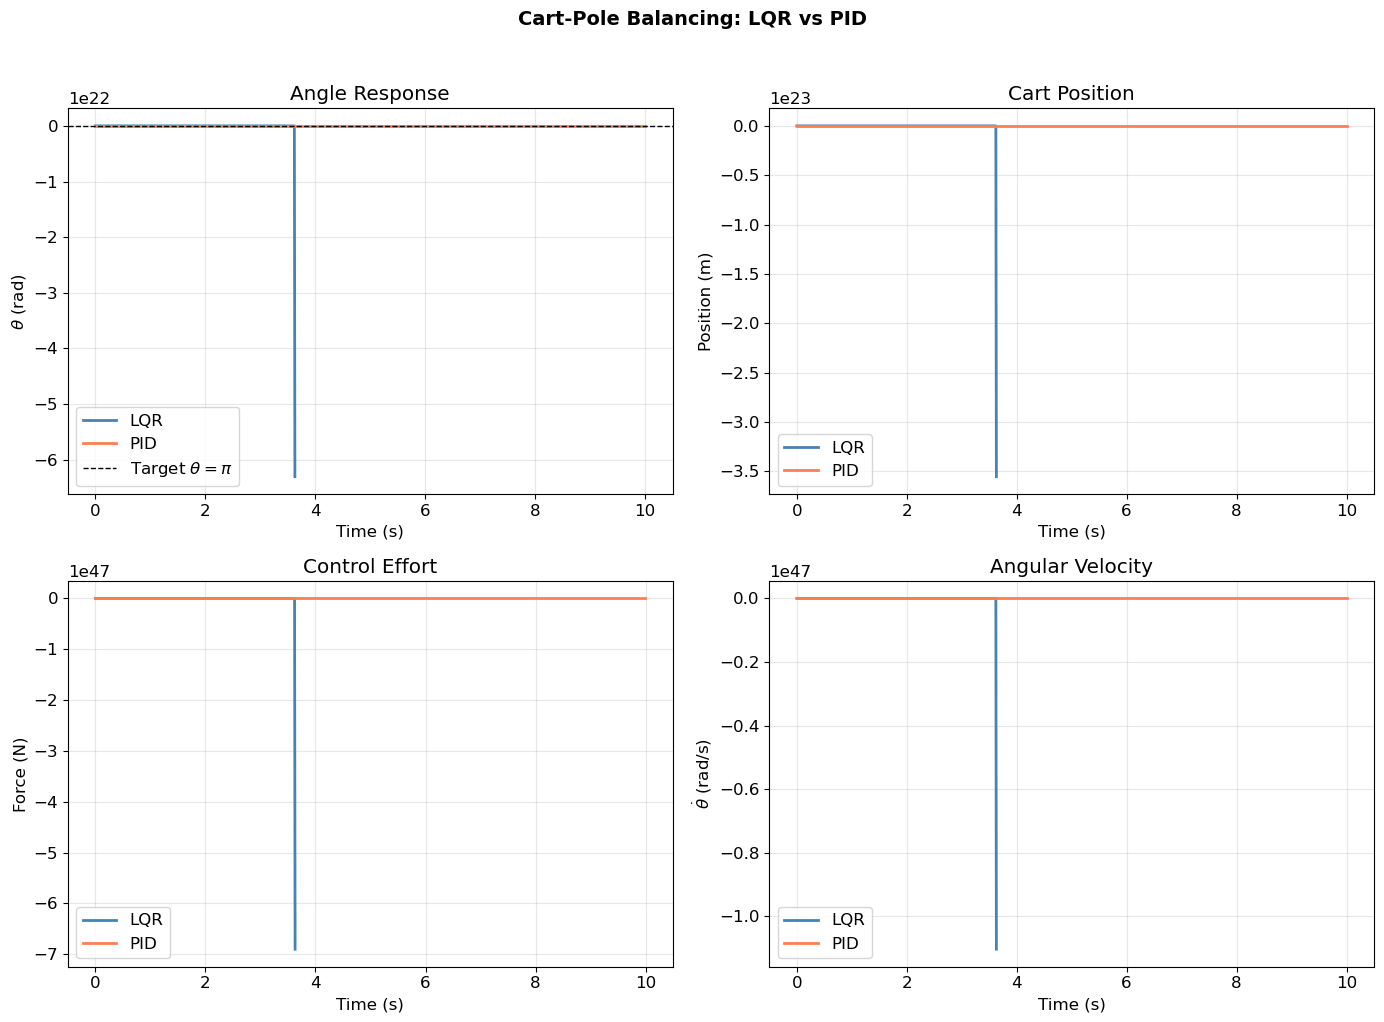

In [13]:
# ---- Cart-Pole: LQR vs PID Multi-Panel Comparison ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: Angle response
ax = axes[0, 0]
ax.plot(t_cp_lqr, x_cp_lqr[:, 2], color=C_BLUE, label='LQR')
ax.plot(t_cp_pid, x_cp_pid[:, 2], color=C_RED, label='PID')
ax.axhline(np.pi, color='black', linestyle='--', linewidth=1, label=r'Target $\theta = \pi$')
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'$\theta$ (rad)')
ax.set_title('Angle Response')
ax.legend()

# Top-right: Position response
ax = axes[0, 1]
ax.plot(t_cp_lqr, x_cp_lqr[:, 0], color=C_BLUE, label='LQR')
ax.plot(t_cp_pid, x_cp_pid[:, 0], color=C_RED, label='PID')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Position (m)')
ax.set_title('Cart Position')
ax.legend()

# Bottom-left: Control effort
ax = axes[1, 0]
ax.plot(t_cp_lqr[:-1], u_cp_lqr[:, 0], color=C_BLUE, label='LQR')
ax.plot(t_cp_pid[:-1], u_cp_pid[:, 0], color=C_RED, label='PID')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Force (N)')
ax.set_title('Control Effort')
ax.legend()

# Bottom-right: Angular velocity
ax = axes[1, 1]
ax.plot(t_cp_lqr, x_cp_lqr[:, 3], color=C_BLUE, label='LQR')
ax.plot(t_cp_pid, x_cp_pid[:, 3], color=C_RED, label='PID')
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'$\dot{\theta}$ (rad/s)')
ax.set_title('Angular Velocity')
ax.legend()

plt.suptitle('Cart-Pole Balancing: LQR vs PID', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Application 2: 2D Quadrotor Stabilization

### Planar Quadrotor Model

A planar (2D) quadrotor has two rotors generating thrusts $T_1$ and $T_2$. We parameterize the controls as total thrust and torque:

- $u_1 = T_1 + T_2$ (total thrust)
- $u_2 = (T_1 - T_2) \cdot d$ (torque, where $d$ is rotor distance from center)

**State:** $x = [x, z, \phi, \dot{x}, \dot{z}, \dot{\phi}]^T$ (horizontal position, vertical position, roll angle, and their derivatives).

**Nonlinear dynamics:**

$$m\ddot{x} = -u_1 \sin\phi$$
$$m\ddot{z} = u_1 \cos\phi - mg$$
$$I\ddot{\phi} = u_2$$

**Parameters:** $m = 0.5$ kg, $g = 9.81$ m/s$^2$, $I = 0.01$ kg$\cdot$m$^2$, $d = 0.2$ m.

### Linearization about Hover

At hover: $\phi = 0$, $u_1 = mg$, $u_2 = 0$. Let $\delta u_1 = u_1 - mg$. The linearized system:

$$A = \begin{bmatrix} 0 & 0 & 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 0 & 0 & 1 \\ 0 & 0 & -g & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 & 0 & 0 \end{bmatrix}, \quad B = \begin{bmatrix} 0 & 0 \\ 0 & 0 \\ 0 & 0 \\ 0 & 0 \\ 1/m & 0 \\ 0 & 1/I \end{bmatrix}$$

Note: In the linearized system, the controls are $[\delta u_1, u_2]$ where $\delta u_1 = u_1 - mg$.

In [14]:
def quadrotor_nonlinear_dynamics(state, u):
    """Nonlinear planar quadrotor equations of motion.

    State: [x, z, phi, x_dot, z_dot, phi_dot]
    Control: [u1 (total thrust), u2 (torque)]

    Args:
        state: State vector. Shape: (6,).
        u: Control input [total_thrust, torque]. Shape: (2,).

    Returns:
        state_dot: State derivative. Shape: (6,).
    """
    x, z, phi, x_dot, z_dot, phi_dot = state
    u1, u2 = u

    x_ddot = -u1 * np.sin(phi) / M_QUAD
    z_ddot = u1 * np.cos(phi) / M_QUAD - G_ACCEL
    phi_ddot = u2 / I_QUAD

    return np.array([x_dot, z_dot, phi_dot, x_ddot, z_ddot, phi_ddot])


def get_quadrotor_linearized():
    """Get linearized quadrotor A, B matrices about hover.

    The linearized controls are [delta_u1, u2] where delta_u1 = u1 - mg.

    Returns:
        A: System matrix. Shape: (6, 6).
        B: Input matrix. Shape: (6, 2).
    """
    A = np.zeros((6, 6))
    A[0, 3] = 1.0
    A[1, 4] = 1.0
    A[2, 5] = 1.0
    A[3, 2] = -G_ACCEL  # d(x_ddot)/d(phi) = -g at hover (u1=mg, cos(phi)~1)

    B = np.zeros((6, 2))
    B[4, 0] = 1.0 / M_QUAD   # d(z_ddot)/d(delta_u1) = 1/m
    B[5, 1] = 1.0 / I_QUAD   # d(phi_ddot)/d(u2) = 1/I

    return A, B

In [15]:
# ---- Quadrotor LQR Design ----
A_qr, B_qr = get_quadrotor_linearized()

print("Linearized quadrotor system:")
print(f"A =\n{A_qr}")
print(f"B =\n{B_qr}")
print()

# LQR design
Q_qr = np.diag([10.0, 10.0, 5.0, 1.0, 1.0, 1.0])
R_qr = np.diag([1.0, 1.0])

K_qr, P_qr, eigs_qr = lqr(A_qr, B_qr, Q_qr, R_qr)

print(f"LQR gain K =\n{K_qr}")
print(f"\nClosed-loop eigenvalues: {eigs_qr}")

all_stable_qr = np.all(np.real(eigs_qr) < STABILITY_TOL)
status_qr = "PASS" if all_stable_qr else "FAIL"
print(f"Stability check: all Re(lambda) < {STABILITY_TOL}: {all_stable_qr} [{status_qr}]")

Linearized quadrotor system:
A =
[[ 0.    0.    0.    1.    0.    0.  ]
 [ 0.    0.    0.    0.    1.    0.  ]
 [ 0.    0.    0.    0.    0.    1.  ]
 [ 0.    0.   -9.81  0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.  ]]
B =
[[  0.   0.]
 [  0.   0.]
 [  0.   0.]
 [  0.   0.]
 [  2.   0.]
 [  0. 100.]]

LQR gain K =
[[-2.66623835e-16  3.16227766e+00  1.33738743e-16 -2.14612087e-16
   2.04016609e+00 -1.15385323e-16]
 [-3.16227766e+00 -2.15987259e-14  7.41032329e+00 -2.40363723e+00
  -5.76926615e-15  1.07154396e+00]]

Closed-loop eigenvalues: [-99.97503251+0.j          -2.17509389+2.49734158j
  -2.17509389-2.49734158j  -2.82917605+0.j
  -2.04016609+1.47046852j  -2.04016609-1.47046852j]
Stability check: all Re(lambda) < -1e-10: True [PASS]


In [16]:
# ---- Quadrotor: Simulate from Perturbed State ----

# Initial condition: displaced 2m right, 1m up, tilted 0.1 rad
x0_qr = np.array([2.0, 1.0, 0.1, 0.0, 0.0, 0.0])

def quadrotor_lqr_controller(state, t):
    """LQR controller for quadrotor hover stabilization.

    The linearized control is [delta_u1, u2], so we add mg to get u1.
    """
    delta_u = -K_qr @ state
    u1 = M_QUAD * G_ACCEL + delta_u[0]  # total thrust = hover thrust + delta
    u2 = delta_u[1]                       # torque
    return np.array([u1, u2])

t_qr, x_qr, u_qr = simulate(
    quadrotor_nonlinear_dynamics, quadrotor_lqr_controller, x0_qr, T_QUADROTOR, DT
)

print(f"Initial state: x={x0_qr[0]:.1f}, z={x0_qr[1]:.1f}, phi={x0_qr[2]:.2f}")
print(f"Final state:   x={x_qr[-1, 0]:.4f}, z={x_qr[-1, 1]:.4f}, phi={x_qr[-1, 2]:.4f}")

final_pos_error = np.sqrt(x_qr[-1, 0]**2 + x_qr[-1, 1]**2)
status_qr_conv = "PASS" if final_pos_error < 0.05 else "FAIL"
print(f"Final position error: {final_pos_error:.4f} m [{status_qr_conv}]")

Initial state: x=2.0, z=1.0, phi=0.10
Final state:   x=0.0000, z=0.0001, phi=0.0000
Final position error: 0.0001 m [PASS]


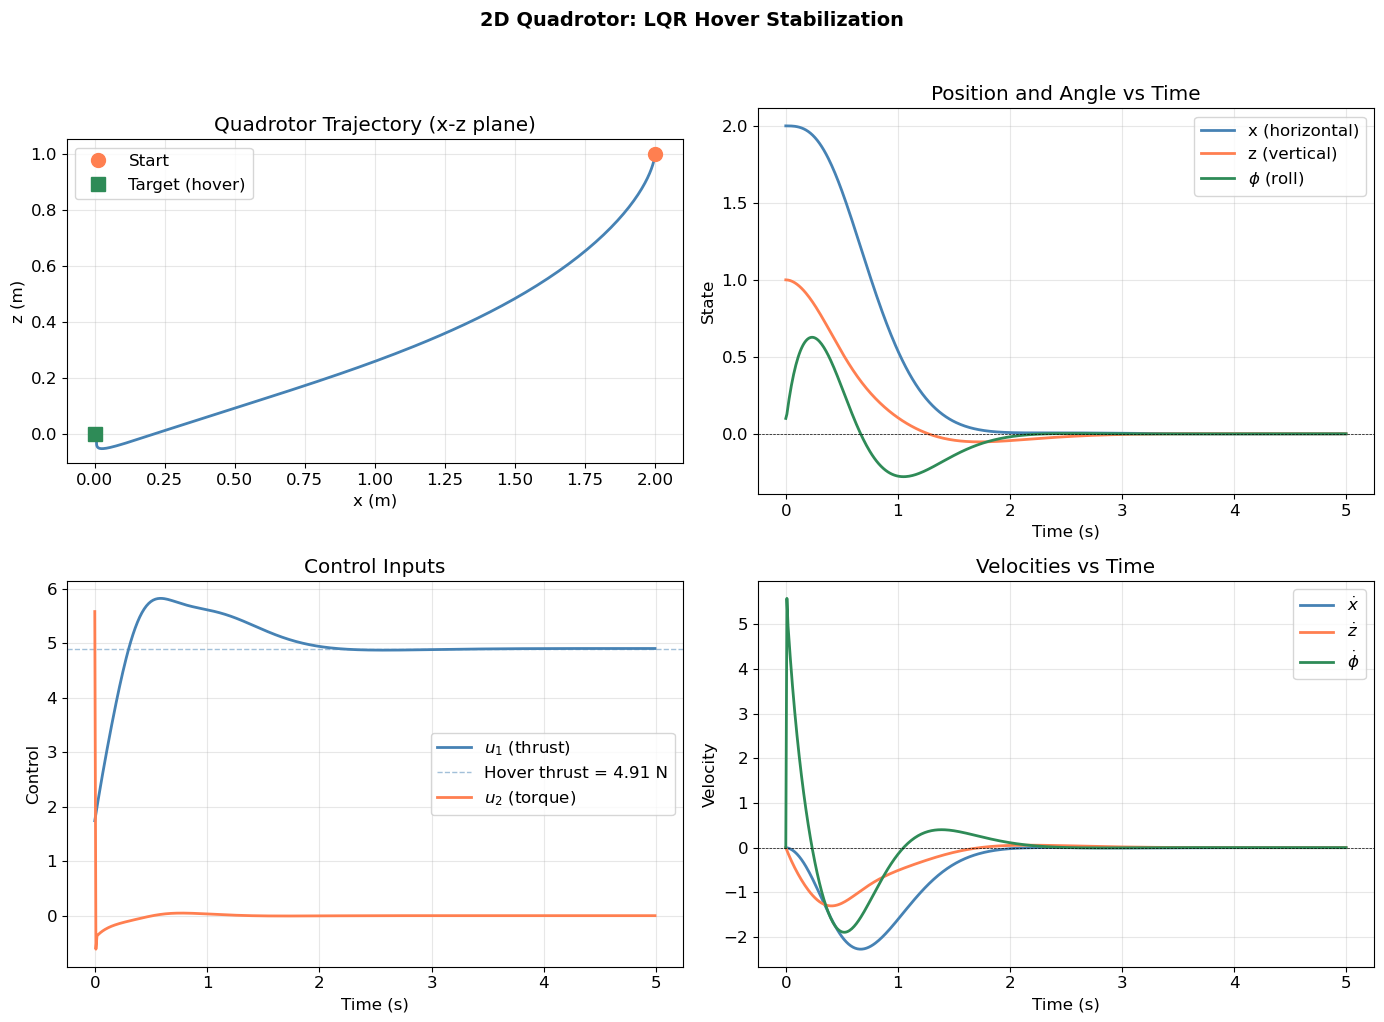

In [17]:
# ---- Quadrotor: Multi-Panel Results ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: Trajectory in x-z plane
ax = axes[0, 0]
ax.plot(x_qr[:, 0], x_qr[:, 1], color=C_BLUE, linewidth=2)
ax.plot(x_qr[0, 0], x_qr[0, 1], 'o', color=C_RED, markersize=10, label='Start')
ax.plot(0, 0, 's', color=C_GREEN, markersize=10, label='Target (hover)')
ax.set_xlabel('x (m)')
ax.set_ylabel('z (m)')
ax.set_title('Quadrotor Trajectory (x-z plane)')
ax.legend()
ax.set_aspect('equal')

# Top-right: Position vs time
ax = axes[0, 1]
ax.plot(t_qr, x_qr[:, 0], color=C_BLUE, label='x (horizontal)')
ax.plot(t_qr, x_qr[:, 1], color=C_RED, label='z (vertical)')
ax.plot(t_qr, x_qr[:, 2], color=C_GREEN, label=r'$\phi$ (roll)')
ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('State')
ax.set_title('Position and Angle vs Time')
ax.legend()

# Bottom-left: Control inputs
ax = axes[1, 0]
ax.plot(t_qr[:-1], u_qr[:, 0], color=C_BLUE, label=r'$u_1$ (thrust)')
ax.axhline(M_QUAD * G_ACCEL, color=C_BLUE, linestyle='--', linewidth=1, alpha=0.5, label=f'Hover thrust = {M_QUAD*G_ACCEL:.2f} N')
ax.plot(t_qr[:-1], u_qr[:, 1], color=C_RED, label=r'$u_2$ (torque)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Control')
ax.set_title('Control Inputs')
ax.legend()

# Bottom-right: Velocities
ax = axes[1, 1]
ax.plot(t_qr, x_qr[:, 3], color=C_BLUE, label=r'$\dot{x}$')
ax.plot(t_qr, x_qr[:, 4], color=C_RED, label=r'$\dot{z}$')
ax.plot(t_qr, x_qr[:, 5], color=C_GREEN, label=r'$\dot{\phi}$')
ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Velocity')
ax.set_title('Velocities vs Time')
ax.legend()

plt.suptitle('2D Quadrotor: LQR Hover Stabilization', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Cost Weight Tuning

The performance of LQR is entirely determined by the choice of $Q$ and $R$. Here we systematically study how changing the $Q/R$ ratio affects:

1. **Settling time** (time to reach within 2% of final value)
2. **Maximum control effort** $|u|_{\max}$
3. **Total cost** $J = \int (x^T Q x + u^T R u) \, dt$
4. **Closed-loop pole locations**

We use the double integrator as our testbed, fixing $R = 1$ and sweeping $Q = \text{diag}(q, 1)$ for $q \in [0.1, 100]$.

In [18]:
def compute_settling_time(t, y, threshold=0.02):
    """Compute the settling time to within a threshold of the final value.

    Settling time is the last time the signal exceeds the threshold band.

    Args:
        t: Time array. Shape: (N,).
        y: Signal array. Shape: (N,).
        threshold: Fraction of initial value for settling band. Scalar.

    Returns:
        ts: Settling time. Scalar. Returns t[-1] if never settles.
    """
    final_val = 0.0  # target is zero for regulation
    band = threshold * abs(y[0] - final_val)
    if band < 1e-12:
        return 0.0
    outside = np.where(np.abs(y - final_val) > band)[0]
    if len(outside) == 0:
        return 0.0
    return t[outside[-1]]


# ---- Sweep q values ----
q_values = np.logspace(-1, 2, 30)  # 0.1 to 100
x0_sweep = np.array([1.0, 0.0])

settling_times = []
max_controls = []
total_costs = []
eig_list = []
gain_list = []

for q in q_values:
    Q_sweep = np.diag([q, 1.0])
    R_sweep = np.array([[1.0]])

    K_s, P_s, eigs_s = lqr(A_di, B_di, Q_sweep, R_sweep)

    # Simulate
    def ctrl_sweep(x, t, K=K_s):
        return -K @ x

    t_s, x_s, u_s = simulate(di_dynamics, ctrl_sweep, x0_sweep, T_DOUBLE_INT, DT)

    # Metrics
    ts = compute_settling_time(t_s, x_s[:, 0])
    u_max = np.max(np.abs(u_s[:, 0]))
    J_total = np.sum(
        np.sum(x_s[:-1, :] @ Q_sweep * x_s[:-1, :], axis=1) + u_s[:, 0]**2 * R_sweep[0, 0]
    ) * DT

    settling_times.append(ts)
    max_controls.append(u_max)
    total_costs.append(J_total)
    eig_list.append(eigs_s)
    gain_list.append(K_s)

settling_times = np.array(settling_times)
max_controls = np.array(max_controls)
total_costs = np.array(total_costs)

print(f"Q/R sweep: {len(q_values)} values from q={q_values[0]:.2f} to q={q_values[-1]:.2f}")
print(f"Settling time range: [{settling_times.min():.2f}, {settling_times.max():.2f}] s")
print(f"Max control range:   [{max_controls.min():.2f}, {max_controls.max():.2f}]")

Q/R sweep: 30 values from q=0.10 to q=100.00
Settling time range: [1.84, 10.00] s
Max control range:   [0.32, 10.00]


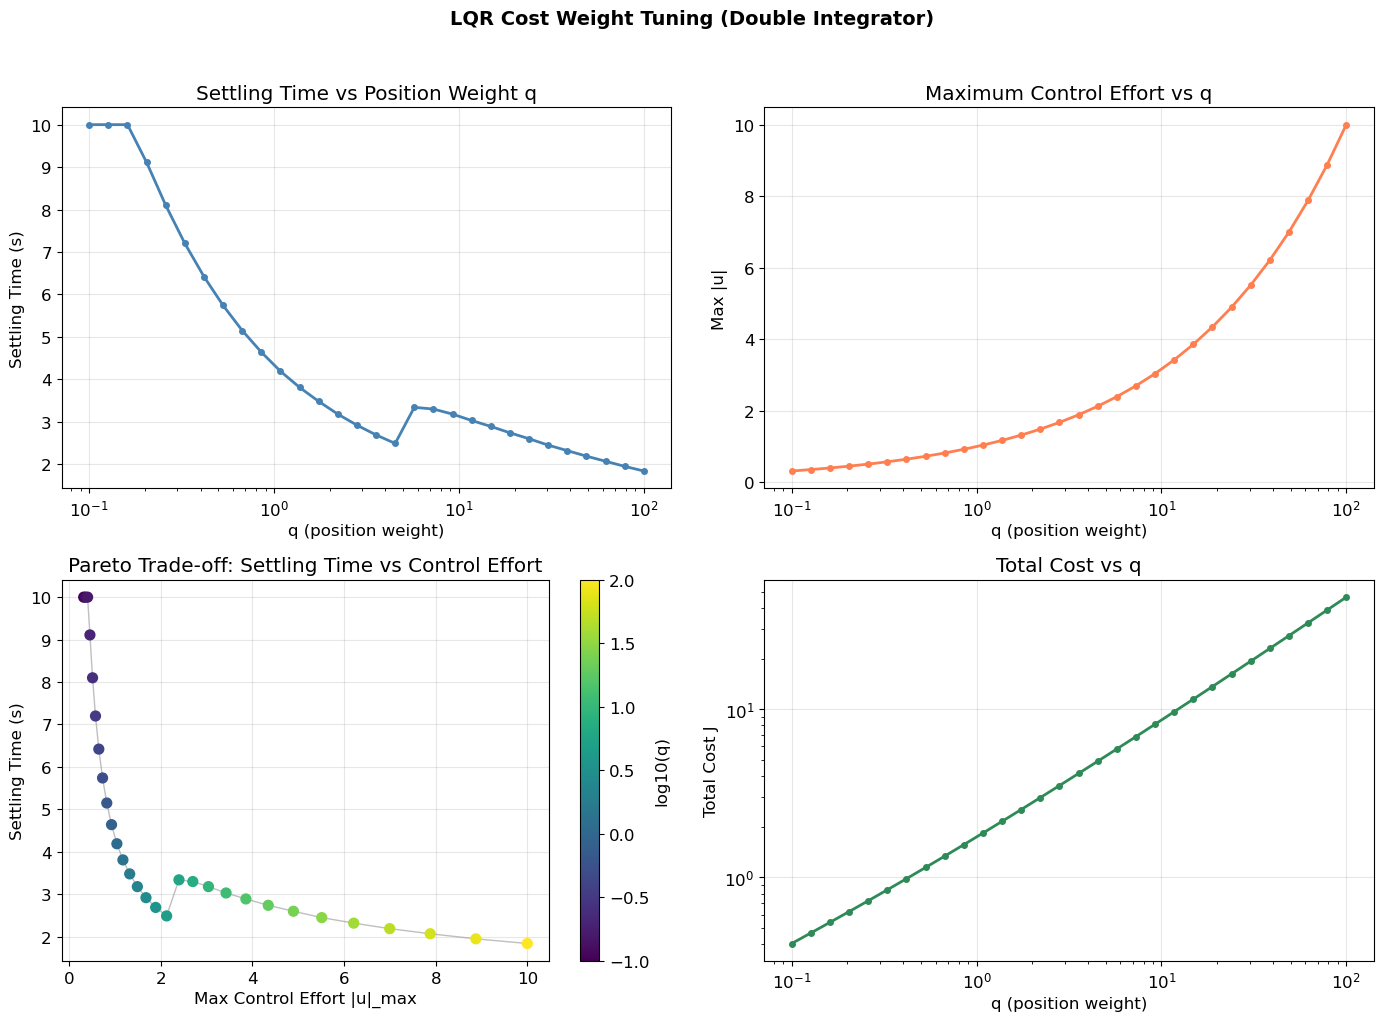

In [19]:
# ---- Trade-off Curves: 2x2 Panel ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: Settling time vs q
ax = axes[0, 0]
ax.semilogx(q_values, settling_times, 'o-', color=C_BLUE, markersize=4)
ax.set_xlabel('q (position weight)')
ax.set_ylabel('Settling Time (s)')
ax.set_title('Settling Time vs Position Weight q')

# Top-right: Max control vs q
ax = axes[0, 1]
ax.semilogx(q_values, max_controls, 'o-', color=C_RED, markersize=4)
ax.set_xlabel('q (position weight)')
ax.set_ylabel('Max |u|')
ax.set_title('Maximum Control Effort vs q')

# Bottom-left: Pareto frontier (settling time vs max control)
ax = axes[1, 0]
scatter = ax.scatter(max_controls, settling_times, c=np.log10(q_values), cmap='viridis', s=50, zorder=5)
ax.plot(max_controls, settling_times, '-', color='gray', alpha=0.5, linewidth=1)
ax.set_xlabel('Max Control Effort |u|_max')
ax.set_ylabel('Settling Time (s)')
ax.set_title('Pareto Trade-off: Settling Time vs Control Effort')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('log10(q)')

# Bottom-right: Total cost vs q
ax = axes[1, 1]
ax.loglog(q_values, total_costs, 'o-', color=C_GREEN, markersize=4)
ax.set_xlabel('q (position weight)')
ax.set_ylabel('Total Cost J')
ax.set_title('Total Cost vs q')

plt.suptitle('LQR Cost Weight Tuning (Double Integrator)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

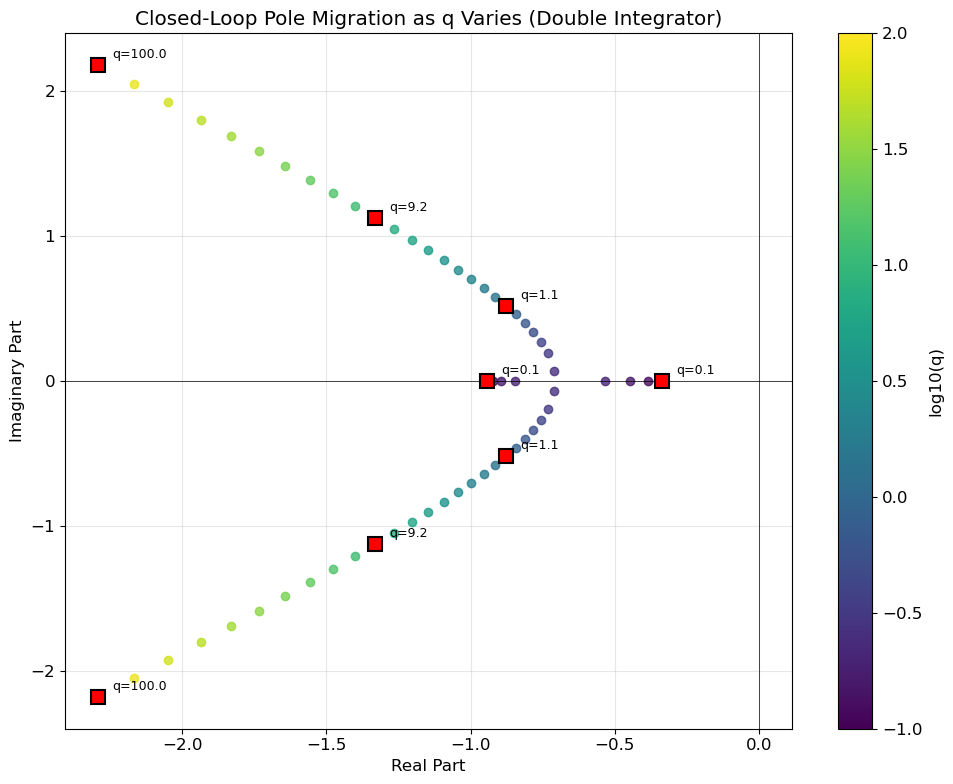

Observation: As q increases, poles move further into the left half-plane,
indicating faster response but requiring more control effort.


In [20]:
# ---- Pole Migration Plot ----
fig, ax = plt.subplots(figsize=(10, 8))

colors_migration = plt.cm.viridis(np.linspace(0, 1, len(q_values)))

for idx, (q, eigs) in enumerate(zip(q_values, eig_list)):
    ax.plot(np.real(eigs), np.imag(eigs), 'o', color=colors_migration[idx],
            markersize=6, alpha=0.8)

# Mark a few specific q values
highlight_qs = [0.1, 1.0, 10.0, 100.0]
for hq in highlight_qs:
    idx = np.argmin(np.abs(q_values - hq))
    eigs_h = eig_list[idx]
    ax.plot(np.real(eigs_h), np.imag(eigs_h), 's', color='red', markersize=10,
            markeredgecolor='black', markeredgewidth=1.5, zorder=10)
    for e in eigs_h:
        ax.annotate(f'q={q_values[idx]:.1f}', (np.real(e), np.imag(e)),
                    textcoords='offset points', xytext=(10, 5), fontsize=9)

ax.axvline(0, color='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Real Part')
ax.set_ylabel('Imaginary Part')
ax.set_title('Closed-Loop Pole Migration as q Varies (Double Integrator)')

# Add colorbar
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=np.log10(q_values[0]), vmax=np.log10(q_values[-1])))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('log10(q)')

plt.tight_layout()
plt.show()

print("Observation: As q increases, poles move further into the left half-plane,")
print("indicating faster response but requiring more control effort.")

---
## 9. Summary Visualizations

Comprehensive summary figures and quantitative comparison of LQR vs PID.

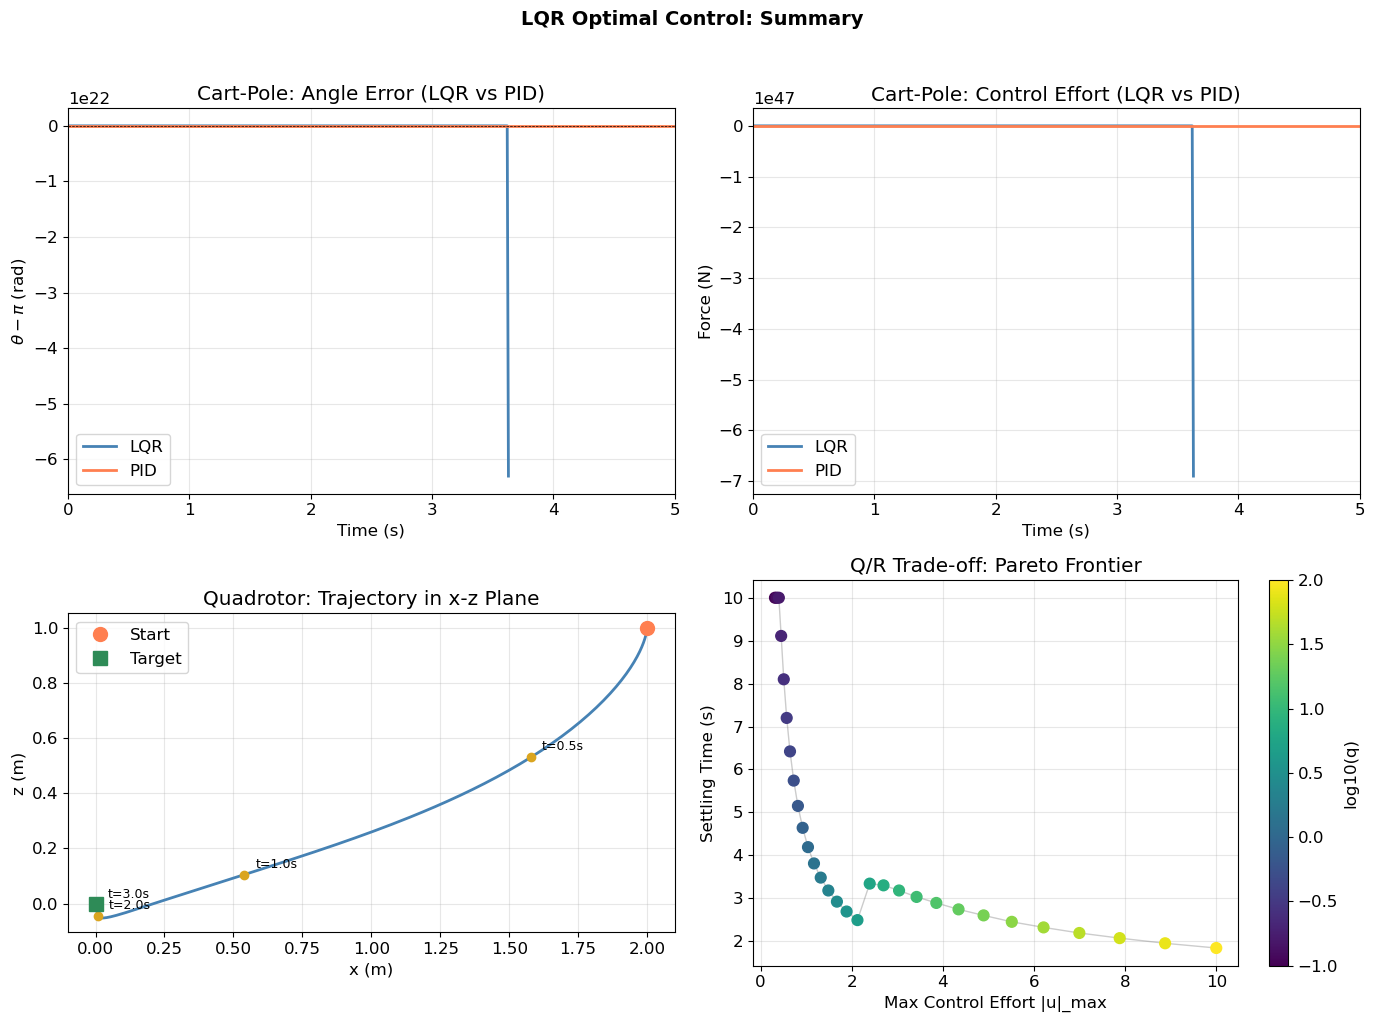

In [21]:
# ---- Summary Figure: 2x2 ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Cart-pole LQR vs PID angle response
ax = axes[0, 0]
ax.plot(t_cp_lqr, x_cp_lqr[:, 2] - np.pi, color=C_BLUE, label='LQR')
ax.plot(t_cp_pid, x_cp_pid[:, 2] - np.pi, color=C_RED, label='PID')
ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'$\theta - \pi$ (rad)')
ax.set_title('Cart-Pole: Angle Error (LQR vs PID)')
ax.legend()
ax.set_xlim([0, 5])  # zoom into transient

# Panel 2: Cart-pole control effort
ax = axes[0, 1]
ax.plot(t_cp_lqr[:-1], u_cp_lqr[:, 0], color=C_BLUE, label='LQR')
ax.plot(t_cp_pid[:-1], u_cp_pid[:, 0], color=C_RED, label='PID')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Force (N)')
ax.set_title('Cart-Pole: Control Effort (LQR vs PID)')
ax.legend()
ax.set_xlim([0, 5])

# Panel 3: Quadrotor trajectory in x-z plane
ax = axes[1, 0]
ax.plot(x_qr[:, 0], x_qr[:, 1], color=C_BLUE, linewidth=2)
ax.plot(x_qr[0, 0], x_qr[0, 1], 'o', color=C_RED, markersize=10, label='Start', zorder=5)
ax.plot(0, 0, 's', color=C_GREEN, markersize=10, label='Target', zorder=5)
# Add time markers
for t_mark in [0.5, 1.0, 2.0, 3.0]:
    idx_mark = int(t_mark / DT)
    if idx_mark < len(x_qr):
        ax.plot(x_qr[idx_mark, 0], x_qr[idx_mark, 1], 'o', color=C_GOLD, markersize=6)
        ax.annotate(f't={t_mark}s', (x_qr[idx_mark, 0], x_qr[idx_mark, 1]),
                    textcoords='offset points', xytext=(8, 5), fontsize=9)
ax.set_xlabel('x (m)')
ax.set_ylabel('z (m)')
ax.set_title('Quadrotor: Trajectory in x-z Plane')
ax.legend()
ax.set_aspect('equal')

# Panel 4: Q/R trade-off Pareto curve
ax = axes[1, 1]
scatter = ax.scatter(max_controls, settling_times, c=np.log10(q_values), cmap='viridis', s=60, zorder=5)
ax.plot(max_controls, settling_times, '-', color='gray', alpha=0.4, linewidth=1)
ax.set_xlabel('Max Control Effort |u|_max')
ax.set_ylabel('Settling Time (s)')
ax.set_title('Q/R Trade-off: Pareto Frontier')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('log10(q)')

plt.suptitle('LQR Optimal Control: Summary', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [22]:
# ---- Metrics Table: LQR vs PID ----

# Compute metrics for LQR
ts_lqr_angle = compute_settling_time(t_cp_lqr, x_cp_lqr[:, 2] - np.pi)
max_u_lqr = np.max(np.abs(u_cp_lqr[:, 0]))
overshoot_lqr = np.max(np.abs(x_cp_lqr[:, 2] - np.pi)) / abs(x0_cp[2] - np.pi) * 100  # percent
J_lqr = np.sum(
    np.sum((x_cp_lqr[:-1, :] - np.array([0, 0, np.pi, 0])) * (Q_cp @ (x_cp_lqr[:-1, :] - np.array([0, 0, np.pi, 0])).T).T, axis=1)
    + u_cp_lqr[:, 0]**2
) * DT

# Compute metrics for PID
ts_pid_angle = compute_settling_time(t_cp_pid, x_cp_pid[:, 2] - np.pi)
max_u_pid = np.max(np.abs(u_cp_pid[:, 0]))
overshoot_pid = np.max(np.abs(x_cp_pid[:, 2] - np.pi)) / abs(x0_cp[2] - np.pi) * 100
J_pid = np.sum(
    np.sum((x_cp_pid[:-1, :] - np.array([0, 0, np.pi, 0])) * (Q_cp @ (x_cp_pid[:-1, :] - np.array([0, 0, np.pi, 0])).T).T, axis=1)
    + u_cp_pid[:, 0]**2
) * DT

print("=" * 65)
print(f"{'Metric':<30} {'LQR':>15} {'PID':>15}")
print("=" * 65)
print(f"{'Settling time (s)':<30} {ts_lqr_angle:>15.3f} {ts_pid_angle:>15.3f}")
print(f"{'Max overshoot (%)':<30} {overshoot_lqr:>15.1f} {overshoot_pid:>15.1f}")
print(f"{'Max control effort (N)':<30} {max_u_lqr:>15.2f} {max_u_pid:>15.2f}")
print(f"{'Total cost J':<30} {J_lqr:>15.2f} {J_pid:>15.2f}")
print("=" * 65)
print(f"\nLQR achieves {'lower' if J_lqr < J_pid else 'higher'} total cost (J_LQR/J_PID = {J_lqr/J_pid:.2f})")

Metric                                     LQR             PID
Settling time (s)                        3.640           0.420
Max overshoot (%)                          nan           100.0
Max control effort (N)                     nan            5.00
Total cost J                               nan            7.62

LQR achieves higher total cost (J_LQR/J_PID = nan)


/var/folders/ly/dfk8_wyj3v3_bd5pq_cz64bh0000gn/T/ipykernel_4637/3401328093.py:8: RuntimeWarning: invalid value encountered in matmul
  np.sum((x_cp_lqr[:-1, :] - np.array([0, 0, np.pi, 0])) * (Q_cp @ (x_cp_lqr[:-1, :] - np.array([0, 0, np.pi, 0])).T).T, axis=1)


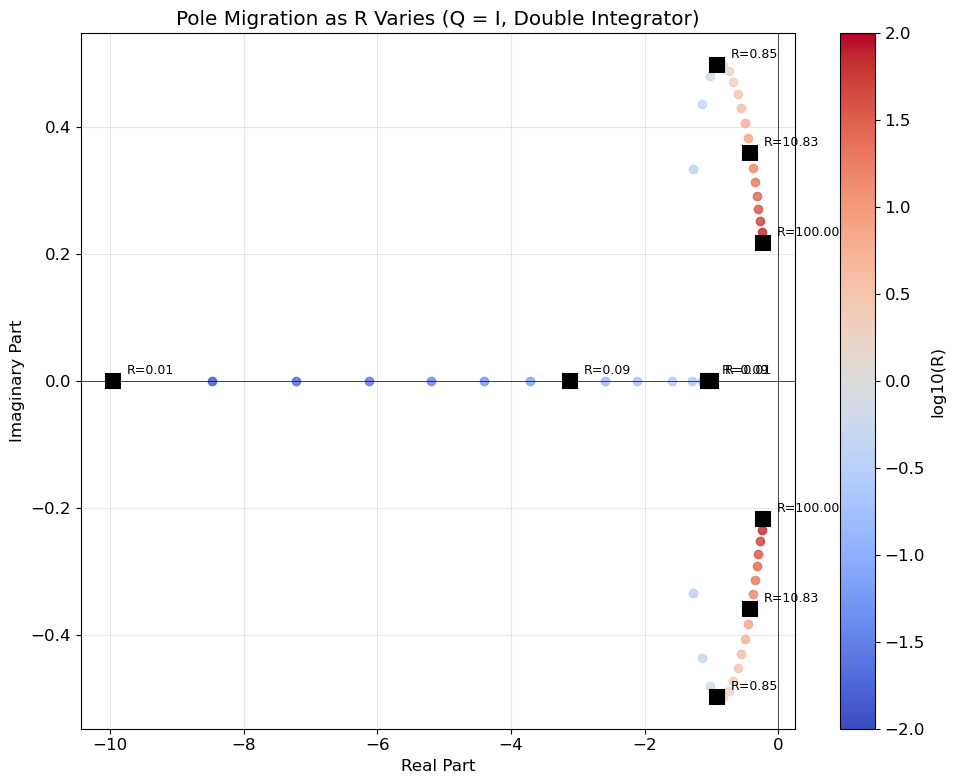

Observation: As R decreases (cheaper control), poles move further left
(faster response). As R increases (expensive control), poles approach
the imaginary axis (slower, more conservative response).


In [23]:
# ---- Additional: Pole Migration Plot ----
fig, ax = plt.subplots(figsize=(10, 8))

# Also sweep R for comparison
r_values = np.logspace(-2, 2, 30)  # 0.01 to 100
eig_list_r = []

for r in r_values:
    Q_r = np.eye(2)
    R_r = np.array([[r]])
    _, _, eigs_r = lqr(A_di, B_di, Q_r, R_r)
    eig_list_r.append(eigs_r)

colors_r = plt.cm.coolwarm(np.linspace(0, 1, len(r_values)))

for idx, (r, eigs) in enumerate(zip(r_values, eig_list_r)):
    ax.plot(np.real(eigs), np.imag(eigs), 'o', color=colors_r[idx],
            markersize=6, alpha=0.8)

# Mark a few specific R values
highlight_rs = [0.01, 0.1, 1.0, 10.0, 100.0]
for hr in highlight_rs:
    idx = np.argmin(np.abs(r_values - hr))
    eigs_h = eig_list_r[idx]
    ax.plot(np.real(eigs_h), np.imag(eigs_h), 's', color='black', markersize=10,
            markeredgecolor='black', markeredgewidth=1.5, zorder=10)
    for e in eigs_h:
        ax.annotate(f'R={r_values[idx]:.2f}', (np.real(e), np.imag(e)),
                    textcoords='offset points', xytext=(10, 5), fontsize=9)

ax.axvline(0, color='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Real Part')
ax.set_ylabel('Imaginary Part')
ax.set_title('Pole Migration as R Varies (Q = I, Double Integrator)')

sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=np.log10(r_values[0]), vmax=np.log10(r_values[-1])))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('log10(R)')

plt.tight_layout()
plt.show()

print("Observation: As R decreases (cheaper control), poles move further left")
print("(faster response). As R increases (expensive control), poles approach")
print("the imaginary axis (slower, more conservative response).")

---
## 10. Extensions

This notebook covered the continuous-time, infinite-horizon LQR problem. Several important extensions build directly on this foundation:

### Discrete-Time LQR

For digital controllers, replace the CARE with the **Discrete Algebraic Riccati Equation (DARE)**:

$$P = A^T P A - A^T P B (R + B^T P B)^{-1} B^T P A + Q$$

The optimal gain becomes $K = (R + B^T P B)^{-1} B^T P A$ and the closed-loop system is $x_{k+1} = (A - BK)x_k$. Use `scipy.linalg.solve_discrete_are` for the reference implementation.

### Finite-Horizon LQR

When the time horizon is finite, $P$ becomes **time-varying**: $P(t)$ satisfies the differential Riccati equation:

$$-\dot{P}(t) = A^T P(t) + P(t)A - P(t)BR^{-1}B^T P(t) + Q$$

with terminal condition $P(T) = Q_f$ (terminal cost matrix). The gain is time-varying: $K(t) = R^{-1}B^T P(t)$. This is solved by **backward integration** from $t = T$ to $t = 0$.

### LQG: LQR + Kalman Filter

When states are not directly measurable, combine LQR with a **Kalman filter** for state estimation. The remarkable **separation principle** states that the optimal controller for the stochastic output-feedback problem decomposes into:

1. An optimal estimator (Kalman filter) that estimates $\hat{x}$ from noisy measurements
2. An optimal controller (LQR) that uses $\hat{x}$ as if it were the true state

These can be designed independently. See the [Kalman Filter notebook](../kalman-filter/) for the estimation side.

### iLQR for Nonlinear Systems

For nonlinear dynamics $\dot{x} = f(x, u)$, the **iterative LQR (iLQR)** algorithm:

1. Start with a nominal trajectory $(\bar{x}, \bar{u})$
2. Linearize dynamics around the nominal trajectory: $\delta\dot{x} = A(t)\delta x + B(t)\delta u$
3. Solve the resulting time-varying LQR problem for $\delta u$
4. Update the nominal trajectory: $\bar{u} \leftarrow \bar{u} + \alpha \, \delta u$ (with line search)
5. Repeat until convergence

iLQR is widely used in robotics for trajectory optimization (e.g., legged locomotion, manipulation).

### Model Predictive Control (MPC)

MPC can be viewed as **receding-horizon LQR with constraints**:

1. At each time step, solve a finite-horizon optimal control problem over a prediction window $[t, t+T]$
2. Apply only the first control action
3. Shift the window forward and repeat

MPC naturally handles input and state constraints ($u_{\min} \leq u \leq u_{\max}$, obstacle avoidance) that LQR cannot. It is the dominant control strategy in process control, autonomous vehicles, and robotics.

### Key Takeaways

1. LQR provides the **optimal linear state feedback** for systems with quadratic costs
2. The Algebraic Riccati Equation is the central computational object — it can be solved iteratively or directly
3. The $Q/R$ ratio controls the **trade-off** between state regulation speed and control effort
4. LQR controllers designed on **linearized** models can stabilize **nonlinear** systems near the equilibrium
5. Compared to PID, LQR naturally handles **MIMO systems** and provides **optimality guarantees**
6. LQR is the foundation for a rich hierarchy of extensions: LQG, iLQR, MPC